(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

C:\Users\Afdal Hussain\AppData\Local\Temp\ipykernel_33156\462505719.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=["#4C9F70", "#E4572E"], ax=ax)


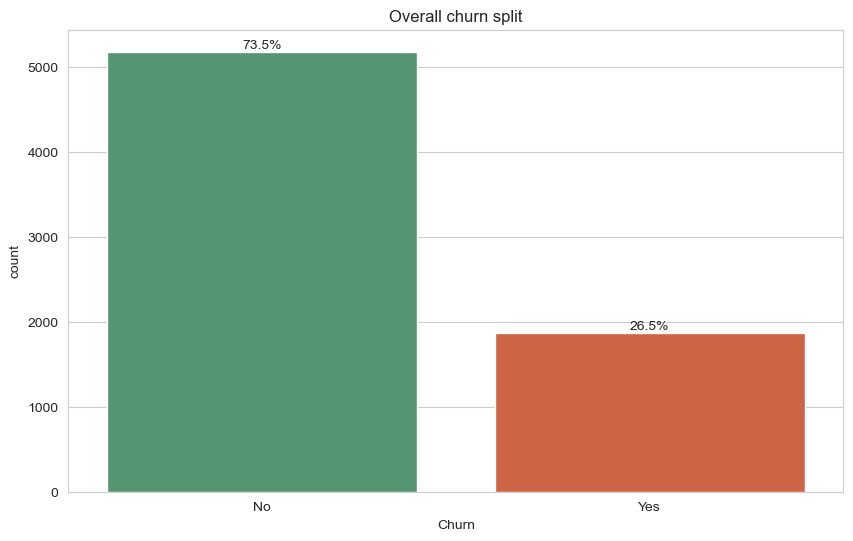

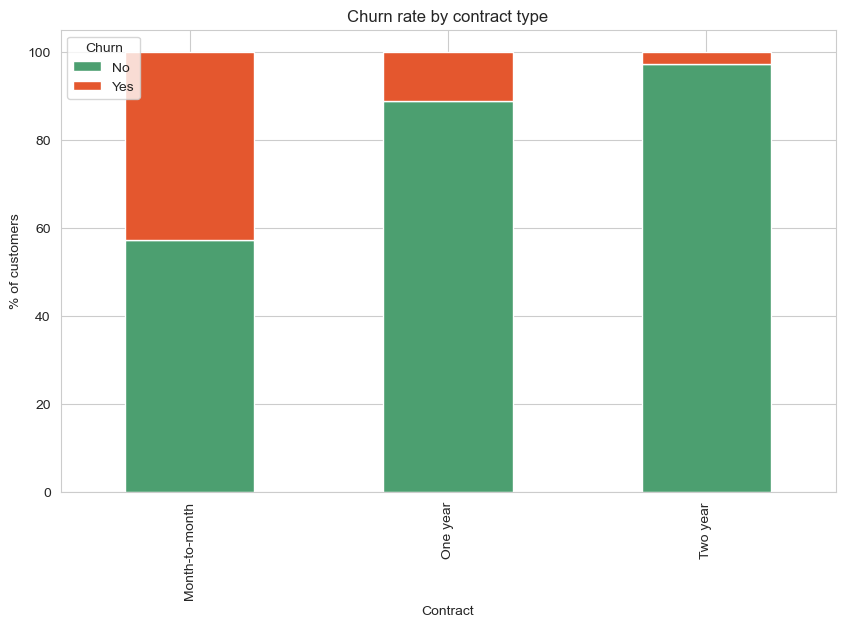

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


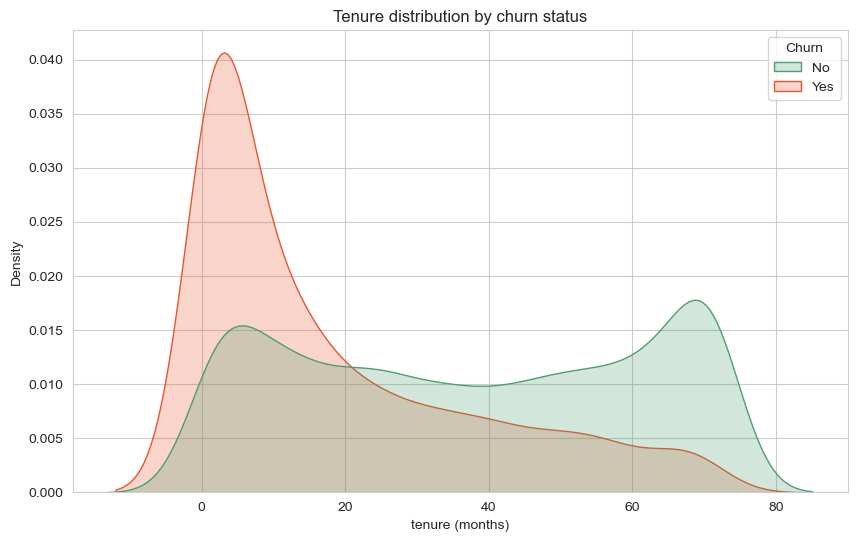

C:\Users\Afdal Hussain\AppData\Local\Temp\ipykernel_33156\462505719.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4C9F70", "#E4572E"], ax=ax)


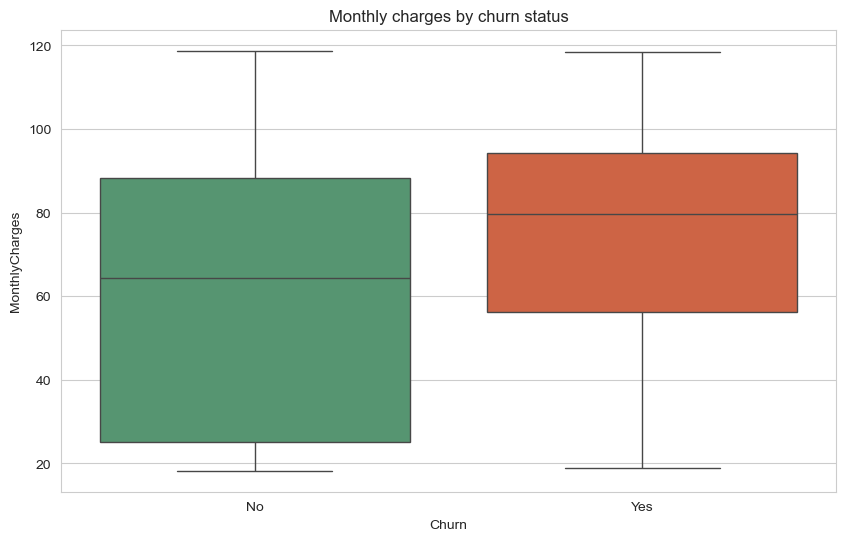

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


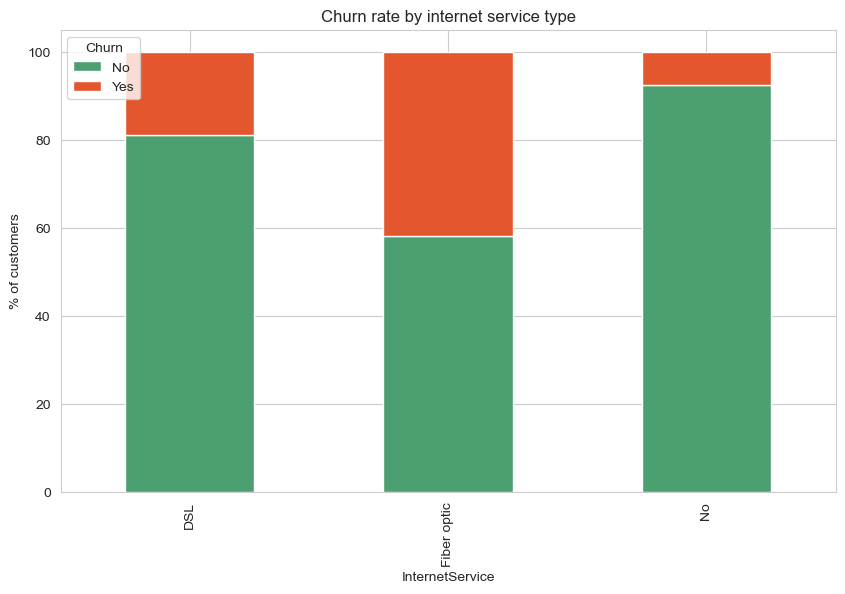

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


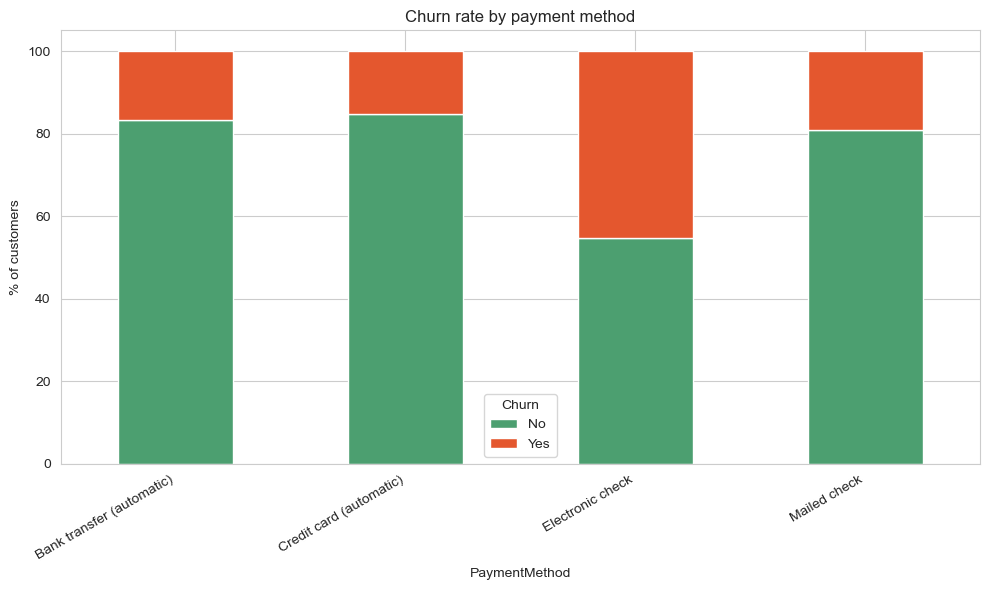

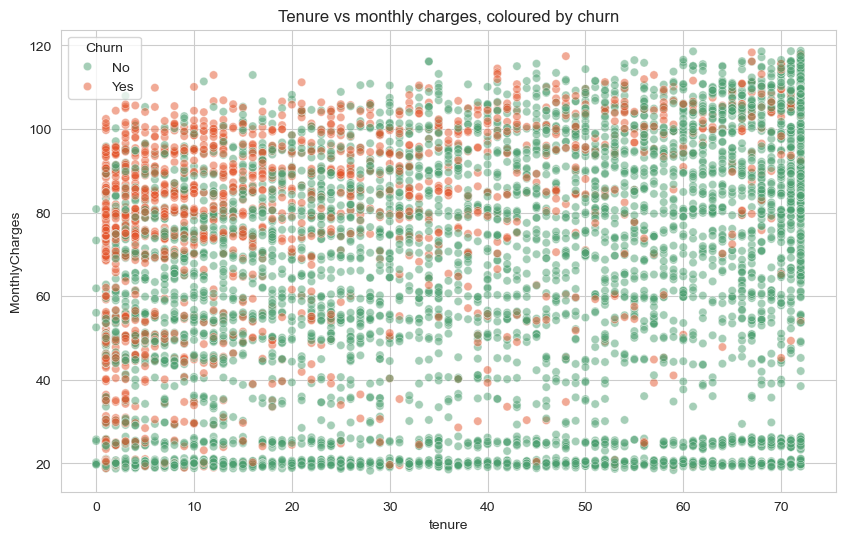

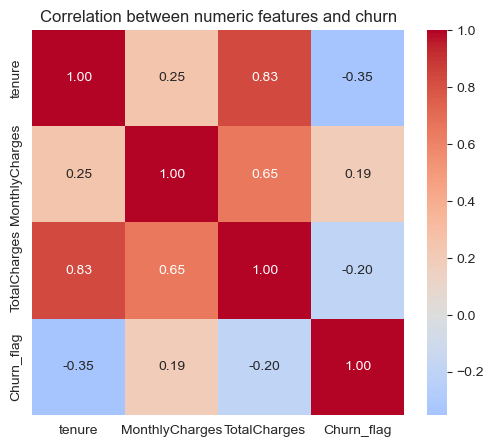

In [1]:
#Telco Customer Churn - EDA
# Quick EDA on the Telco Customer Churn dataset. Goal here isn't to build a model - it's to actually understand who churns and why, using the data to tell that story rather than just running .describe() and calling it a day.
# Dataset: IBM's Telco Customer Churn sample (7,043 customers, 21 columns)

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 50)

DATA_PATH = Path(r"C:\Users\Afdal Hussain\Desktop\Python Projects\Datasets\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head(3)


df.info()


df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
blank_rows = df["TotalCharges"].isna().sum()
print(f"{blank_rows} rows had a blank TotalCharges")

df.loc[df["TotalCharges"].isna(), ["tenure", "TotalCharges"]]


#All 11 of them have `tenure == 0` - brand new customers who haven't been billed yet.
#Makes sense that TotalCharges would be blank rather than a "real" missing value, so filling with 0 is the right call here (not the column mean or anything like that).


df["TotalCharges"] = df["TotalCharges"].fillna(0)

# customerID is just a unique identifier, no analytical value - drop it
df = df.drop(columns=["customerID"])

#how many customers actually churn?

churn_rate = df["Churn"].value_counts(normalize=True)
print(churn_rate)

fig, ax = plt.subplots()
sns.countplot(data=df, x="Churn", palette=["#4C9F70", "#E4572E"], ax=ax)
ax.set_title("Overall churn split")
for p in ax.patches:
    ax.annotate(f"{p.get_height()/len(df):.1%}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


#About 1 in 4 customers has churned (26.5%). Not a rare event by any means - this is a real, sizeable retention problem, not a needle-in-a-haystack detection task.
#the single biggest lever?

fig, ax = plt.subplots()
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar", stacked=True, ax=ax, color=["#4C9F70", "#E4572E"])
ax.set_ylabel("% of customers")
ax.set_title("Churn rate by contract type")
plt.show()

print(contract_churn)

#Huge gap here. Month-to-month customers churn at a much higher rate than one-year or two-year contract holders, unsurprising when you think about it (no lock-in means no friction to leave), but the scale of the difference is striking. If I were advising the business, pushing month-to-month customers onto annual contracts would be priority #1.
#Does tenure matter? (Are new customers the flight risk?)

fig, ax = plt.subplots()
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, common_norm=False,
            palette=["#4C9F70", "#E4572E"], ax=ax)
ax.set_title("Tenure distribution by churn status")
ax.set_xlabel("tenure (months)")
plt.show()


#Churned customers are heavily concentrated in the low-tenure range, a lot of people leave within the first few months. The longer someone sticks around, the less likely they are to churn. This lines up with the contract finding above: new, unlocked-in customers are the highest-risk group.
#Does price play a role?

fig, ax = plt.subplots()
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4C9F70", "#E4572E"], ax=ax)
ax.set_title("Monthly charges by churn status")
plt.show()

print(df.groupby("Churn")["MonthlyCharges"].median())

#Service type - is internet service a factor?

fig, ax = plt.subplots()
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_churn.plot(kind="bar", stacked=True, ax=ax, color=["#4C9F70", "#E4572E"])
ax.set_ylabel("% of customers")
ax.set_title("Churn rate by internet service type")
plt.show()

print(internet_churn)


#Fiber optic customers churn at close to double the rate of DSL customers, and customers with no internet service at all churn the least. Combined with the price finding above,
#Fiber is the priciest tier, and it's also the leakiest.
#Worth digging into fiber-specific complaints/pricing if this were a live business problem.

#Payment method (a smaller but real signal)

fig, ax = plt.subplots(figsize=(10, 6))
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment_churn.plot(kind="bar", stacked=True, ax=ax, color=["#4C9F70", "#E4572E"])
ax.set_ylabel("% of customers")
ax.set_title("Churn rate by payment method")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


#Electronic check stands out, the churn rate there is noticeably higher than the other three payment methods, which are all pretty similar to each other. Electronic check is also
#The only fully manual, non-automatic option in the list. Potentially could be a proxy for lower engagement/commitment rather than the payment method itself causing anything.

#Putting tenure and price together


fig, ax = plt.subplots()
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.5,
                 palette=["#4C9F70", "#E4572E"], ax=ax)
ax.set_title("Tenure vs monthly charges, coloured by churn")
plt.show()


#Correlation check (numeric features only)


df_encoded = df.copy()
df_encoded["Churn_flag"] = (df_encoded["Churn"] == "Yes").astype(int)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_flag"]
corr = df_encoded[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric features and churn")
plt.show()


#Key takeaways
#**Churn rate is 26.5%** - a real, sizeable retention problem, not a rare edge case.
#**Contract type is the biggest single lever** - month-to-month customers churn far more than those on annual contracts.
#**New customers are the highest risk** - churn is concentrated in the first few months of tenure.
#**It's not about being cheap** - churned customers pay *more* per month on average, pointing to a value/experience issue rather than pure price sensitivity.
#**Fiber optic + electronic check are risk flags** - both show meaningfully higher churn rates than their alternatives.
#**Highest-risk profile**: a new, fiber-optic customer on a month-to-month contract, paying a high monthly rate, and paying by electronic check.

#Possible next steps
#Build a simple logistic regression / random forest to rank these features by predictive importance rather than eyeballing crosstabs
#Segment customers into risk tiers and estimate revenue at risk per tier
#Look at `OnlineSecurity` / `TechSupport` / `StreamingTV` add-ons - haven't touched those yet, might reveal whether bundling more services reduces churn